In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! tar -xvf /content/drive/MyDrive/project_2/MSD/Task04_Hippocampus.tar

./._Task04_Hippocampus
Task04_Hippocampus/
Task04_Hippocampus/._.DS_Store
Task04_Hippocampus/.DS_Store
Task04_Hippocampus/._labelsTr
Task04_Hippocampus/labelsTr/
Task04_Hippocampus/._imagesTr
Task04_Hippocampus/imagesTr/
Task04_Hippocampus/._imagesTs
Task04_Hippocampus/imagesTs/
Task04_Hippocampus/._dataset.json
Task04_Hippocampus/dataset.json
Task04_Hippocampus/imagesTs/hippocampus_267.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_379.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_208.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_275.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_131.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_140.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_076.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_115.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_168.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_119.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_021.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_121.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_38

In [ ]:
import os
from glob import glob

img_paths = sorted(glob("/content/Task04_Hippocampus/imagesTr/*.nii.gz"))
lab_paths = sorted(glob("/content/Task04_Hippocampus/labelsTr/*.nii.gz"))

assert len(img_paths) == len(lab_paths), (len(img_paths), len(lab_paths))

# 파일명 기준 매칭 체크(강력 추천)
def stem(p):
    return os.path.basename(p).replace(".nii.gz","")

img_stems = [stem(p) for p in img_paths]
lab_stems = [stem(p) for p in lab_paths]
assert img_stems == lab_stems, "imagesTr/labelsTr 파일명이 1:1로 정렬/매칭되지 않습니다."

print("cases:", len(img_paths))
print("example:", img_paths[0], lab_paths[0])

cases: 260
example: /content/Task04_Hippocampus/imagesTr/hippocampus_001.nii.gz /content/Task04_Hippocampus/labelsTr/hippocampus_001.nii.gz


In [ ]:
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset
import scipy.ndimage as ndimage

class MSDHippocampus3DDataset(Dataset):
    def __init__(self, img_paths, lab_paths, patch_size=(96,96,96), samples_per_volume=4, binary=True, augment=False):
        self.img_paths = img_paths
        self.lab_paths = lab_paths
        self.patch_size = np.array(patch_size)
        self.samples_per_volume = samples_per_volume
        self.binary = binary
        self.augment = augment # ✅ 수정됨: 증강 활성화 플래그 추가

    def __len__(self):
        return len(self.img_paths) * self.samples_per_volume

    def _load_case(self, idx):
        vidx = idx // self.samples_per_volume
        img = np.squeeze(nib.load(self.img_paths[vidx]).get_fdata()).astype(np.float32)
        lab = np.squeeze(nib.load(self.lab_paths[vidx]).get_fdata()).astype(np.int16)
        return img, lab

    def _zscore_nonzero(self, x):
        mask = x != 0
        if mask.sum() < 10:
            mean, std = x.mean(), x.std() + 1e-8
            return (x - mean) / std
        mean = x[mask].mean()
        std  = x[mask].std() + 1e-8
        x = (x - mean) / std
        return x

    # ✅ 수정됨: 데이터 증강 메서드 추가
    def _augment_data(self, img, lab):
        # 1. Random Rotation (-15 ~ 15 degree)
        if np.random.rand() < 0.2:
            angle = np.random.uniform(-15, 15)
            # axes=(0,1)은 z축 기준 회전 (depth 방향)
            img = ndimage.rotate(img, angle, axes=(0,1), reshape=False, order=1, mode='constant', cval=0)
            lab = ndimage.rotate(lab, angle, axes=(0,1), reshape=False, order=0, mode='constant', cval=0)

        # 2. Random Scaling (0.85 ~ 1.15)
        if np.random.rand() < 0.2:
            scale = np.random.uniform(0.85, 1.15)
            img = ndimage.zoom(img, zoom=scale, order=1)
            lab = ndimage.zoom(lab, zoom=scale, order=0)

        # 3. Gaussian Noise
        if np.random.rand() < 0.15:
            noise = np.random.normal(0, 0.1, size=img.shape)
            img = img + noise

        return img, lab

    def _pad_to_patch(self, img, lab):
        H, W, D = img.shape
        ph, pw, pd = map(int, self.patch_size)

        pad_h = max(0, ph - H)
        pad_w = max(0, pw - W)
        pad_d = max(0, pd - D)

        if pad_h or pad_w or pad_d:
            pad = (
                (pad_h//2, pad_h - pad_h//2),
                (pad_w//2, pad_w - pad_w//2),
                (pad_d//2, pad_d - pad_d//2),
            )
            img = np.pad(img, pad, mode="constant", constant_values=0)
            lab = np.pad(lab, pad, mode="constant", constant_values=0)

        return img, lab

    def _random_patch(self, img, lab):
        # ✅ 증강 적용 위치 (패딩 전 원본에 적용)
        if self.augment:
            img, lab = self._augment_data(img, lab)

        img, lab = self._pad_to_patch(img, lab)

        H, W, D = img.shape
        ph, pw, pd = map(int, self.patch_size)

        # Patch 크기보다 이미지가 작아진 경우(Scaling down 등으로) 다시 방어
        if H < ph or W < pw or D < pd:
             img, lab = self._pad_to_patch(img, lab)
             H, W, D = img.shape

        fg = np.argwhere(lab > 0)
        use_fg = (len(fg) > 0) and (np.random.rand() < 0.7)

        if use_fg:
            cx, cy, cz = fg[np.random.randint(len(fg))]
        else:
            cx = np.random.randint(0, H)
            cy = np.random.randint(0, W)
            cz = np.random.randint(0, D)

        x1 = int(np.clip(cx - ph//2, 0, H - ph))
        y1 = int(np.clip(cy - pw//2, 0, W - pw))
        z1 = int(np.clip(cz - pd//2, 0, D - pd))

        img_p = img[x1:x1+ph, y1:y1+pw, z1:z1+pd]
        lab_p = lab[x1:x1+ph, y1:y1+pw, z1:z1+pd]

        return img_p, lab_p

    def __getitem__(self, idx):
        img, lab = self._load_case(idx)
        img = self._zscore_nonzero(img)

        img_p, lab_p = self._random_patch(img, lab)

        if self.binary:
            lab_p = (lab_p > 0).astype(np.int64)
        else:
            lab_p = lab_p.astype(np.int64)

        img_p = np.ascontiguousarray(img_p.astype(np.float32))
        lab_p = np.ascontiguousarray(lab_p)

        img_t = torch.tensor(img_p[None, ...], dtype=torch.float32)
        if self.binary:
            lab_t = torch.tensor(lab_p[None, ...], dtype=torch.int64)
        else:
            lab_t = torch.tensor(lab_p, dtype=torch.long)

        return img_t, lab_t

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

BATCH = 8

train_imgs, val_imgs, train_labs, val_labs = train_test_split(
    img_paths, lab_paths, test_size=0.2, random_state=42
)

train_ds = MSDHippocampus3DDataset(train_imgs, train_labs, patch_size=(96,96,96), samples_per_volume=4, binary=False)
val_ds   = MSDHippocampus3DDataset(val_imgs,   val_labs,   patch_size=(96,96,96), samples_per_volume=2, binary=False)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

x, y = next(iter(train_loader))
print(x.shape, y.shape, x.dtype, y.unique())

torch.Size([8, 1, 96, 96, 96]) torch.Size([8, 96, 96, 96]) torch.float32 tensor([0, 1, 2])


In [ ]:
import math
from dataclasses import dataclass
from typing import List, Tuple, Optional, Union, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F


# -------------------------
# Utils
# -------------------------
def conv3d_bn_gelu(in_ch, out_ch, k=3, s=1, p=1, groups=1):
    return nn.Sequential(
        nn.Conv3d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, groups=groups, bias=False),
        nn.BatchNorm3d(out_ch),
        nn.GELU(),
    )

def pointwise3d(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv3d(in_ch, out_ch, kernel_size=1, bias=False),
        nn.BatchNorm3d(out_ch),
        nn.GELU(),
    )

def _ensure_divisible(x: torch.Tensor, patch_size: Tuple[int, int, int]) -> Tuple[torch.Tensor, Tuple[int,int,int]]:
    """Pad (H,W,D) so each is divisible by patch_size; return padded tensor and pad sizes."""
    _, _, H, W, D = x.shape
    ph, pw, pd = patch_size
    pad_h = (ph - H % ph) % ph
    pad_w = (pw - W % pw) % pw
    pad_d = (pd - D % pd) % pd
    # F.pad uses (D_left, D_right, W_left, W_right, H_left, H_right)
    x = F.pad(x, (0, pad_d, 0, pad_w, 0, pad_h))
    return x, (pad_h, pad_w, pad_d)

def _unpad(x: torch.Tensor, pad_hw_d: Tuple[int,int,int]) -> torch.Tensor:
    pad_h, pad_w, pad_d = pad_hw_d
    if pad_h == pad_w == pad_d == 0:
        return x
    _, _, H, W, D = x.shape
    return x[:, :, :H-pad_h, :W-pad_w, :D-pad_d]


# -------------------------
# FMCA (MCA inside)
# -------------------------
class MCA3D(nn.Module):
    """
    Implements MCA described by Eq.(1)-(3), with multi-branch DW conv kernels 3,3,5.
    - F1 = DwConv(F)
    - Weight = Conv1x1(F1 + sum_i Scale_i(DwConv(F1)))
    - Output = Weight ⊗ F1
    """
    def __init__(self, channels: int):
        super().__init__()
        # DwConv for F1 (k=3, s=1, p=1), groups=channels
        self.dw_agg = nn.Conv3d(channels, channels, kernel_size=3, stride=1, padding=1,
                                groups=channels, bias=False)

        # Two branches to cover kernel sizes (3 and 5). (Paper lists 3,3,5 overall.)
        self.dw_b3 = nn.Conv3d(channels, channels, kernel_size=3, stride=1, padding=1,
                               groups=channels, bias=False)
        self.dw_b5 = nn.Conv3d(channels, channels, kernel_size=5, stride=1, padding=2,
                               groups=channels, bias=False)

        # 1x1x1 conv to learn channel relationships, used as attention weight
        self.pw = nn.Conv3d(channels, channels, kernel_size=1, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        f1 = self.dw_agg(x)
        # multi-scale context from branches
        b3 = self.dw_b3(f1)
        b5 = self.dw_b5(f1)
        weight = self.pw(f1 + b3 + b5)
        return weight * f1  # element-wise (⊗)


class FMCA3D(nn.Module):
    """
    A practical FMCA block:
    - local conv (3x3x3 + BN + GELU)
    - MCA attention on the local feature
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.local = conv3d_bn_gelu(in_ch, out_ch, k=3, s=1, p=1)
        self.mca = MCA3D(out_ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.local(x)
        x = self.mca(x)
        return x


# -------------------------
# 3D MobileViT (Transformer as "convolution")
# -------------------------
class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int = 4, mlp_ratio: float = 2.0, dropout: float = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, N, dim)
        h = self.norm1(x)
        h, _ = self.attn(h, h, h, need_weights=False)
        x = x + h
        h = self.mlp(self.norm2(x))
        x = x + h
        return x


class MobileViT3DBlock(nn.Module):
    """
    3D-MobileViT summary:
    - 3x3x3 conv + 1x1x1 conv -> XL in F-dim (F > C)
    - unfold XL to patches: XU in (B, F, P, N), P=ph*pw*pd, N=(H*W*D)/P
    - for each p in [0..P-1], run Transformer over N tokens (across patches)
    - fold back -> XE
    - point-wise conv reduce to C, concat with original X, fuse by 3x3x3 conv
    Patch size: 2x2x2, heads=4, transformer layers=1 (paper setting).
    """
    def __init__(
        self,
        in_ch: int,
        patch_size: Tuple[int, int, int] = (2, 2, 2),
        num_heads: int = 4,
        transformer_depth: int = 1,
        f_dim: Optional[int] = None,
        mlp_ratio: float = 2.0,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.in_ch = in_ch
        self.patch_size = patch_size
        self.num_heads = num_heads
        self.transformer_depth = transformer_depth

        if f_dim is None:
            f_dim = in_ch * 2  # F > C (paper)
        self.f_dim = f_dim

        self.conv_local = conv3d_bn_gelu(in_ch, in_ch, k=3, s=1, p=1)
        self.conv_proj = pointwise3d(in_ch, f_dim)   # to F-dim

        # Transformer blocks (repeated once in paper setting)
        self.transformer = nn.Sequential(*[
            TransformerEncoderBlock(dim=f_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, dropout=dropout)
            for _ in range(transformer_depth)
        ])

        self.conv_reduce = pointwise3d(f_dim, in_ch)  # back to C
        self.conv_fuse = conv3d_bn_gelu(in_ch * 2, in_ch, k=3, s=1, p=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W, D)
        residual = x
        x = self.conv_local(x)
        x = self.conv_proj(x)  # (B, F, H, W, D)

        x, pad = _ensure_divisible(x, self.patch_size)
        B, Fch, H, W, D = x.shape
        ph, pw, pd = self.patch_size
        gh, gw, gd = H // ph, W // pw, D // pd
        P = ph * pw * pd
        N = gh * gw * gd

        # Unfold into patches (non-overlapping)
        # reshape to (B, F, gh, ph, gw, pw, gd, pd) then permute to gather patch pixels
        x_ = x.view(B, Fch, gh, ph, gw, pw, gd, pd)
        # (B, F, gh, gw, gd, ph, pw, pd)
        x_ = x_.permute(0, 1, 2, 4, 6, 3, 5, 7).contiguous()
        # (B, F, N, P)
        x_ = x_.view(B, Fch, N, P)
        # (B, F, P, N)
        x_u = x_.permute(0, 1, 3, 2).contiguous()

        # Transformer across patches per pixel position p:
        # make (B*P, N, F)
        x_tokens = x_u.permute(0, 2, 3, 1).contiguous()  # (B, P, N, F)
        x_tokens = x_tokens.view(B * P, N, Fch)

        x_tokens = self.transformer(x_tokens)  # (B*P, N, F)

        # back to (B, F, P, N)
        x_tokens = x_tokens.view(B, P, N, Fch).permute(0, 3, 1, 2).contiguous()

        # Fold back:
        # (B, F, P, N) -> (B, F, N, P)
        x_fold = x_tokens.permute(0, 1, 3, 2).contiguous()
        # (B, F, gh, gw, gd, ph, pw, pd)
        x_fold = x_fold.view(B, Fch, gh, gw, gd, ph, pw, pd)
        # inverse permute to (B, F, gh, ph, gw, pw, gd, pd)
        x_fold = x_fold.permute(0, 1, 2, 5, 3, 6, 4, 7).contiguous()
        # (B, F, H, W, D)
        x_fold = x_fold.view(B, Fch, H, W, D)

        x_fold = _unpad(x_fold, pad)

        # Reduce + concat + fuse
        x_fold = self.conv_reduce(x_fold)  # (B, C, H0, W0, D0)
        x_cat = torch.cat([x_fold, residual], dim=1)
        out = self.conv_fuse(x_cat)
        return out

# -------------------------
# Decoders (수정됨)
# -------------------------
class RFSDecoder(nn.Module):
    # RFS는 기존 코드가 논문과 일치함
    def __init__(self, c4: int, c1: int, num_classes: int):
        super().__init__()
        self.adjust = nn.Conv3d(c4, c1, kernel_size=1, bias=False)

        def two_conv_block(ch: int) -> nn.Sequential:
            return nn.Sequential(
                conv3d_bn_gelu(ch, ch, 3, 1, 1),
                conv3d_bn_gelu(ch, ch, 3, 1, 1),
            )

        self.block1 = two_conv_block(c1)
        self.block2 = two_conv_block(c1)
        self.out = nn.Conv3d(c1, num_classes, kernel_size=1)

    def forward(self, x4: torch.Tensor, out_size: Tuple[int,int,int]) -> torch.Tensor:
        x = F.interpolate(x4, size=out_size, mode="trilinear", align_corners=False)
        x = self.adjust(x)
        x = self.block1(x)
        x = self.block2(x)
        return self.out(x)


class PFSDecoder(nn.Module):
    """
    PFS:
    - 논문 Fig 5(b) Legend 참고: (Conv3x3x3 + BN + GELU)x2 사용
    """
    def __init__(self, c2: int, c3: int, c4: int, c1: int, num_classes: int, deep_supervision: bool = True):
        super().__init__()
        self.deep_supervision = deep_supervision

        # ✅ 수정됨: 단순 conv3d_bn_gelu -> 2번 반복하는 블록으로 변경
        def double_conv(in_ch, out_ch):
            return nn.Sequential(
                conv3d_bn_gelu(in_ch, out_ch, 3, 1, 1),
                conv3d_bn_gelu(out_ch, out_ch, 3, 1, 1)
            )

        self.fuse3 = double_conv(c4 + c3, c3)
        self.fuse2 = double_conv(c3 + c2, c2)
        self.fuse1 = double_conv(c2 + c1, c1)

        self.head3 = nn.Conv3d(c3, num_classes, 1)
        self.head2 = nn.Conv3d(c2, num_classes, 1)
        self.head1 = nn.Conv3d(c1, num_classes, 1)

    def forward(self, x1, x2, x3, x4, out_size):
        # x4 -> up to x3 size
        x = F.interpolate(x4, size=x3.shape[2:], mode="trilinear", align_corners=False)
        x = self.fuse3(torch.cat([x, x3], dim=1))
        out3 = self.head3(x)

        # -> up to x2 size
        x = F.interpolate(x, size=x2.shape[2:], mode="trilinear", align_corners=False)
        x = self.fuse2(torch.cat([x, x2], dim=1))
        out2 = self.head2(x)

        # -> up to x1 size (full res)
        x = F.interpolate(x, size=x1.shape[2:], mode="trilinear", align_corners=False)
        x = self.fuse1(torch.cat([x, x1], dim=1))
        out1 = self.head1(x)

        out1 = F.interpolate(out1, size=out_size, mode="trilinear", align_corners=False)
        out2 = F.interpolate(out2, size=out_size, mode="trilinear", align_corners=False)
        out3 = F.interpolate(out3, size=out_size, mode="trilinear", align_corners=False)

        if self.deep_supervision:
            return [out1, out2, out3]
        return out1

class WeightedFusion(nn.Module):
    """BiFPN-style normalized weighted sum: sum(w_i * x_i) / (sum(w_i) + eps)."""
    def __init__(self, n_inputs: int, eps: float = 1e-4):
        super().__init__()
        self.eps = eps
        self.w = nn.Parameter(torch.ones(n_inputs, dtype=torch.float32))

    def forward(self, xs: List[torch.Tensor]) -> torch.Tensor:
        w = F.relu(self.w)
        w_sum = torch.sum(w) + self.eps
        out = 0.0
        for i, x in enumerate(xs):
            out = out + w[i] * x
        return out / w_sum


class DWConvBNGELU(nn.Module):
    """Depth-wise conv + BN + GELU."""
    def __init__(self, ch: int, k: int = 3, p: int = 1):
        super().__init__()
        self.op = nn.Sequential(
            nn.Conv3d(ch, ch, kernel_size=k, padding=p, groups=ch, bias=False),
            nn.BatchNorm3d(ch),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.op(x)


class MFSDecoder(nn.Module):
    """
    MFS (BiFPN-like):
    - ✅ 수정됨: 끊겨있던 Bottom-up 경로 연결 (p1_2 계산 추가)
    """
    def __init__(self, c1: int, c2: int, c3: int, c4: int, num_classes: int, fpn_ch: int = 48):
        super().__init__()
        self.fpn_ch = fpn_ch
        self.adj1 = nn.Conv3d(c1, fpn_ch, 1, bias=False)
        self.adj2 = nn.Conv3d(c2, fpn_ch, 1, bias=False)
        self.adj3 = nn.Conv3d(c3, fpn_ch, 1, bias=False)
        self.adj4 = nn.Conv3d(c4, fpn_ch, 1, bias=False)

        # top-down fusions
        self.fuse3_td = WeightedFusion(2)
        self.fuse2_td = WeightedFusion(2)
        self.fuse1_td = WeightedFusion(2)

        self.dw3_td = DWConvBNGELU(fpn_ch)
        self.dw2_td = DWConvBNGELU(fpn_ch)
        self.dw1_td = DWConvBNGELU(fpn_ch)

        # bottom-up fusions
        self.fuse2_bu = WeightedFusion(3)
        self.fuse3_bu = WeightedFusion(2)
        self.fuse4_bu = WeightedFusion(2)

        # ✅ 추가됨: P1 레벨의 최종 Bottom-up 퓨전 (논문 Fig 5c의 마지막 노드 p1_2 대응)
        self.fuse1_bu = WeightedFusion(2)

        self.dw2_bu = DWConvBNGELU(fpn_ch)
        self.dw3_bu = DWConvBNGELU(fpn_ch)
        self.dw4_bu = DWConvBNGELU(fpn_ch)
        # ✅ 추가됨
        self.dw1_bu = DWConvBNGELU(fpn_ch)

        self.out = nn.Conv3d(fpn_ch, num_classes, 1)

    def forward(self, x1, x2, x3, x4, out_size):
        p1 = self.adj1(x1)
        p2 = self.adj2(x2)
        p3 = self.adj3(x3)
        p4 = self.adj4(x4)

        # --- top-down ---
        p4_td = p4
        p3_1 = self.dw3_td(self.fuse3_td([p3, F.interpolate(p4_td, size=p3.shape[2:], mode="trilinear", align_corners=False)]))
        p2_1 = self.dw2_td(self.fuse2_td([p2, F.interpolate(p3_1, size=p2.shape[2:], mode="trilinear", align_corners=False)]))
        p1_1 = self.dw1_td(self.fuse1_td([p1, F.interpolate(p2_1, size=p1.shape[2:], mode="trilinear", align_corners=False)]))

        # --- bottom-up ---
        # P2_2는 P2_0, P2_1, P3_1(resized)가 합쳐짐
        p2_2 = self.dw2_bu(self.fuse2_bu([
            p2,
            p2_1,
            F.interpolate(p3_1, size=p2.shape[2:], mode="trilinear", align_corners=False), # 원래 논문에서는 Downsample일 수도 있으나 코드 맥락상 Resize 유지
        ]))

        # ✅ 수정됨: Bottom-up 흐름이 끊기지 않고 위로(해상도 높은 쪽) 전달되어야 함
        # 하지만 논문 Fig 5(c)는 P2->P3->P4로 가는 일반적 BiFPN과 달리 복잡함.
        # 여기서는 가장 확실한 "Top-down -> Bottom-up" 구조로 P1의 최종 피처(p1_2)를 만듭니다.

        p1_2 = self.dw1_bu(self.fuse1_bu([
            p1_1, # Top-down 결과
            F.interpolate(p2_2, size=p1.shape[2:], mode="trilinear", align_corners=False) # Bottom-up에서 올라온 것
        ]))

        # (필요시 p3_2, p4_2 등도 계산 가능하나, Segmentation은 고해상도인 P1 출력이 중요)

        # Use finest feature (p1_2) for segmentation
        y = self.out(p1_2)
        y = F.interpolate(y, size=out_size, mode="trilinear", align_corners=False)
        return y


# -------------------------
# Light3DHS (Encoder + selectable Decoder)
# -------------------------
@dataclass
class Light3DHSConfig:
    in_channels: int = 1
    num_classes: int = 3
    # encoder channels
    c1: int = 16
    c2: int = 32
    c3: int = 64
    c4: int = 128
    # mobilevit
    patch_size: Tuple[int,int,int] = (2,2,2)
    num_heads: int = 4
    transformer_depth: int = 1
    # decoder
    decoder: str = "pfs"  # "rfs" | "pfs" | "mfs"
    deep_supervision: bool = True  # only for PFS


class Light3DHS(nn.Module):
    def __init__(self, cfg: Light3DHSConfig):
        super().__init__()
        self.cfg = cfg

        # Stage 1-2: FMCA conv stage
        self.enc1 = FMCA3D(cfg.in_channels, cfg.c1)
        self.down1 = nn.Sequential(
            nn.MaxPool3d(kernel_size=2, stride=2),
            nn.GELU(),
        )

        self.enc2 = FMCA3D(cfg.c1, cfg.c2)
        self.down2 = nn.Sequential(
            nn.MaxPool3d(kernel_size=2, stride=2),
            nn.GELU(),
        )

        # Stage 3-4: MobileViT stage (3D)
        self.enc3 = nn.Sequential(
            conv3d_bn_gelu(cfg.c2, cfg.c3, 3, 1, 1),
            MobileViT3DBlock(
                in_ch=cfg.c3,
                patch_size=cfg.patch_size,
                num_heads=cfg.num_heads,
                transformer_depth=cfg.transformer_depth,
            )
        )
        self.down3 = nn.Sequential(
            nn.MaxPool3d(kernel_size=2, stride=2),
            nn.GELU(),
        )

        self.enc4 = nn.Sequential(
            conv3d_bn_gelu(cfg.c3, cfg.c4, 3, 1, 1),
            MobileViT3DBlock(
                in_ch=cfg.c4,
                patch_size=cfg.patch_size,
                num_heads=cfg.num_heads,
                transformer_depth=cfg.transformer_depth,
            )
        )

        # Decoder selection
        dec = cfg.decoder.lower()
        if dec == "rfs":
            self.decoder = RFSDecoder(cfg.c4, cfg.c1, cfg.num_classes)
        elif dec == "pfs":
            self.decoder = PFSDecoder(cfg.c2, cfg.c3, cfg.c4, cfg.c1, cfg.num_classes, deep_supervision=cfg.deep_supervision)
        elif dec == "mfs":
            self.decoder = MFSDecoder(cfg.c1, cfg.c2, cfg.c3, cfg.c4, cfg.num_classes, fpn_ch=48)
        else:
            raise ValueError(f"Unknown decoder: {cfg.decoder}")

    def forward(self, x: torch.Tensor) -> Union[torch.Tensor, List[torch.Tensor]]:
        """
        x: (B, in_channels, H, W, D)
        returns:
          - RFS/MFS: (B, num_classes, H, W, D)
          - PFS (deep_supervision=True): [out_full, out_full, out_full] (3 outputs)
        """
        out_size = x.shape[2:]

        x1 = self.enc1(x)         # X1_0
        x2 = self.enc2(self.down1(x1))  # X2_0
        x3 = self.enc3(self.down2(x2))  # X3_0
        x4 = self.enc4(self.down3(x3))  # X4_0

        if isinstance(self.decoder, RFSDecoder):
            return self.decoder(x4, out_size)
        if isinstance(self.decoder, PFSDecoder):
            return self.decoder(x1, x2, x3, x4, out_size)
        if isinstance(self.decoder, MFSDecoder):
            return self.decoder(x1, x2, x3, x4, out_size)

        raise RuntimeError("Decoder not initialized correctly.")


# -------------------------
# Quick sanity test
# -------------------------
if __name__ == "__main__":
    cfg = Light3DHSConfig(in_channels=1, num_classes=3, decoder="pfs", deep_supervision=True)
    model = Light3DHS(cfg)

    x = torch.randn(2, 1, 64, 64, 64)
    y = model(x)

    if isinstance(y, list):
        print("PFS outputs:", [t.shape for t in y])
    else:
        print("Output:", y.shape)

PFS outputs: [torch.Size([2, 3, 64, 64, 64]), torch.Size([2, 3, 64, 64, 64]), torch.Size([2, 3, 64, 64, 64])]


In [ ]:
import os
from dataclasses import dataclass
from typing import List, Tuple, Union, Optional, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm


# ============================================================
# 1) Loss: Dice + CE (nnU-Net style)
# ============================================================
class DiceLoss(nn.Module):
    """
    Soft Dice Loss (multi-class)
    - expects logits (B, C, ...)
    - target: (B, ...) int64 class indices
    """
    def __init__(self, smooth: float = 1e-5, include_background: bool = True):
        super().__init__()
        self.smooth = smooth
        self.include_background = include_background

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        num_classes = logits.shape[1]
        probs = torch.softmax(logits, dim=1)

        # one-hot: (B, C, ...)
        target_1h = F.one_hot(target.long(), num_classes=num_classes).permute(0, -1, *range(1, target.ndim)).contiguous()
        target_1h = target_1h.to(probs.dtype)

        if not self.include_background and num_classes > 1:
            probs = probs[:, 1:]
            target_1h = target_1h[:, 1:]

        # flatten
        probs_f = probs.reshape(probs.shape[0], probs.shape[1], -1)
        target_f = target_1h.reshape(target_1h.shape[0], target_1h.shape[1], -1)

        intersect = (probs_f * target_f).sum(-1)
        denom = probs_f.sum(-1) + target_f.sum(-1)

        dice = (2.0 * intersect + self.smooth) / (denom + self.smooth)
        loss = 1.0 - dice  # (B, C)
        return loss.mean()


class DiceCELoss(nn.Module):
    """
    Dice + CrossEntropy
    """
    def __init__(
        self,
        dice_weight: float = 1.0,
        ce_weight: float = 1.0,
        include_background_in_dice: bool = True,
        ce_ignore_index: Optional[int] = None,
    ):
        super().__init__()
        self.dice = DiceLoss(include_background=include_background_in_dice)
        self.ce = nn.CrossEntropyLoss(ignore_index=ce_ignore_index) if ce_ignore_index is not None else nn.CrossEntropyLoss()
        self.dw = dice_weight
        self.cw = ce_weight

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return self.dw * self.dice(logits, target) + self.cw * self.ce(logits, target)


# ============================================================
# 2) Deep Supervision wrapper (PFS outputs: 3 logits)
# ============================================================
class DeepSupervisionLoss(nn.Module):
    """
    outputs: list of logits [out1, out2, out3] (all already resized to full res in our decoder)
    target: (B, H, W, D)
    weights: typical nnU-Net style uses decreasing weights, e.g., [1.0, 0.5, 0.25]
    """
    def __init__(self, base_loss: nn.Module, weights: Optional[List[float]] = None):
        super().__init__()
        self.base_loss = base_loss
        self.weights = weights if weights is not None else [1.0, 0.5, 0.25]

    def forward(self, outputs: Union[torch.Tensor, List[torch.Tensor]], target: torch.Tensor) -> torch.Tensor:
        if isinstance(outputs, torch.Tensor):
            return self.base_loss(outputs, target)

        assert isinstance(outputs, list), "DeepSupervisionLoss expects Tensor or List[Tensor]"
        w = self.weights[: len(outputs)]
        # normalize (optional, but stable)
        s = sum(w)
        w = [wi / s for wi in w]

        loss = 0.0
        for out, wi in zip(outputs, w):
            loss = loss + wi * self.base_loss(out, target)
        return loss


# ============================================================
# 3) Poly LR Scheduler (nnU-Net style)
# ============================================================
def set_poly_lr(optimizer: torch.optim.Optimizer, base_lr: float, cur_iter: int, max_iter: int, power: float = 0.9):
    lr = base_lr * (1.0 - float(cur_iter) / float(max_iter)) ** power
    for pg in optimizer.param_groups:
        pg["lr"] = lr
    return lr


# ============================================================
# 4) Metrics (simple)
# ============================================================
@torch.no_grad()
def dice_per_class_from_logits(logits: torch.Tensor, target: torch.Tensor, num_classes: int) -> List[float]:
    pred = torch.argmax(logits, dim=1)  # (B, ...)
    dices = []
    for c in range(num_classes):
        pred_c = (pred == c).float()
        targ_c = (target == c).float()
        inter = (pred_c * targ_c).sum()
        denom = pred_c.sum() + targ_c.sum()
        d = (2 * inter + 1e-5) / (denom + 1e-5)
        dices.append(d.item())
    return dices


# ============================================================
# 5) Training config
# ============================================================
@dataclass
class TrainConfig:
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    amp: bool = True

    # optimizer
    lr: float = 1e-3
    weight_decay: float = 0.0

    # poly schedule
    poly_power: float = 0.9
    max_epochs: int = 200

    # deep supervision weights (PFS only)
    ds_weights: Tuple[float, float, float] = (1.0, 0.5, 0.25)

    # checkpoint
    save_dir: str = "./checkpoints"
    save_name: str = "light3dhs_best.pth"

    # logging
    print_every: int = 20


# ============================================================
# 7) Train / Val loops
# ============================================================
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    cfg: TrainConfig,
    epoch: int,
    global_iter: int,
    max_iter: int,
):
    model.train()
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.amp and cfg.device.startswith("cuda")))

    running_loss = 0.0
    for step, (x, y) in tqdm(enumerate(loader)):
        x = x.to(cfg.device, non_blocking=True)              # (B, C, H, W, D)
        y = y.to(cfg.device, non_blocking=True)              # (B, H, W, D)

        # poly lr update per-iter
        lr = set_poly_lr(optimizer, cfg.lr, global_iter, max_iter, power=cfg.poly_power)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(cfg.amp and cfg.device.startswith("cuda"))):
            out = model(x)
            loss = loss_fn(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        global_iter += 1

        if (step + 1) % cfg.print_every == 0:
            avg = running_loss / (step + 1)
            print(f"[Train] epoch={epoch} step={step+1}/{len(loader)} loss={avg:.4f} lr={lr:.6g}")

    return running_loss / max(1, len(loader)), global_iter


@torch.no_grad()
def validate(
    model: nn.Module,
    loader: DataLoader,
    num_classes: int,
    cfg: TrainConfig,
):
    model.eval()

    total_loss = 0.0
    # validation에서는 deep supervision이면 "첫 번째 output(가장 강한)"로 dice 계산하는 게 보편적
    # (loss는 학습에서만 쓰는 용도로 단순화 가능)
    dices_sum = [0.0 for _ in range(num_classes)]
    n_batches = 0

    for x, y in loader:
        x = x.to(cfg.device, non_blocking=True)
        y = y.to(cfg.device, non_blocking=True)

        out = model(x)
        if isinstance(out, list):
            logits = out[0]
        else:
            logits = out

        dices = dice_per_class_from_logits(logits, y, num_classes=num_classes)
        for c in range(num_classes):
            dices_sum[c] += dices[c]

        n_batches += 1

    dices_mean = [d / max(1, n_batches) for d in dices_sum]
    mean_fg = sum(dices_mean[1:]) / max(1, (num_classes - 1)) if num_classes > 1 else dices_mean[0]
    return dices_mean, mean_fg


# ============================================================
# 8) Full training runner
# ============================================================
def run_training(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, num_classes: int, cfg: TrainConfig):
    os.makedirs(cfg.save_dir, exist_ok=True)
    save_path = os.path.join(cfg.save_dir, cfg.save_name)

    model = model.to(cfg.device)

    # Optimizer: Adam (paper)  [oai_citation:2‡1-s2.0-S1053811924001034-main.pdf](sediment://file_000000009b04720797cdbb0de9ee8285)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    # Loss: Dice + CE (paper)  [oai_citation:3‡1-s2.0-S1053811924001034-main.pdf](sediment://file_000000009b04720797cdbb0de9ee8285)
    base_loss = DiceCELoss(dice_weight=1.0, ce_weight=1.0, include_background_in_dice=True)

    # Deep supervision (PFS: 3 outputs)  [oai_citation:4‡1-s2.0-S1053811924001034-main.pdf](sediment://file_000000009b04720797cdbb0de9ee8285)
    loss_fn = DeepSupervisionLoss(base_loss, weights=list(cfg.ds_weights))

    # max_iter for poly schedule
    max_iter = cfg.max_epochs * len(train_loader)
    global_iter = 0

    best_score = -1.0

    for epoch in tqdm(range(1, cfg.max_epochs + 1)):
        train_loss, global_iter = train_one_epoch(
            model, train_loader, optimizer, loss_fn, cfg, epoch, global_iter, max_iter
        )

        dices_mean, mean_fg = validate(model, val_loader, num_classes=num_classes, cfg=cfg)

        print(f"[Val] epoch={epoch} train_loss={train_loss:.4f} "
              f"dice_per_class={['%.3f'%d for d in dices_mean]} mean_fg={mean_fg:.3f}")

        # checkpoint (best mean_fg)
        if mean_fg > best_score:
            best_score = mean_fg
            torch.save(
                {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "best_score": best_score,
                    "cfg": cfg.__dict__,
                },
                save_path,
            )
            print(f"✅ Saved best checkpoint to: {save_path} (best_mean_fg={best_score:.3f})")

In [ ]:
# 모델 cfg
NUM_CLASSES = 3

cfg_model = Light3DHSConfig(
    in_channels=1,          # CT/MRI/volume 1채널이면 1, 다채널이면 수정
    num_classes=NUM_CLASSES,          # background 포함 3클래스
    decoder="pfs",          # deep supervision 있는 PFS 권장
    deep_supervision=True,

    # 논문 채널 설정
    c1=16, c2=32, c3=64, c4=128,

    # MobileViT 설정 (논문)
    patch_size=(2,2,2),
    num_heads=4,
    transformer_depth=1,
)

model = Light3DHS(cfg_model)

# 학습 cfg
cfg_train = TrainConfig(
    lr=1e-3,
    weight_decay=1e-4,      # ✅ 수정됨: 논문 수치 (0.0001)
    max_epochs=100,         # ✅ 수정됨: 논문 수치 (100)
    poly_power=0.9,
    amp=True,
    ds_weights=(1.0, 0.5, 0.25),
    print_every=10,         # 로그 너무 많으면 10 정도로 조절 추천
    save_dir="/content/drive/MyDrive/project_2",
    save_name="best_Light3DHS.pth",
)

In [ ]:
run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=NUM_CLASSES,
    cfg=cfg_train
)

  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipython-input-877474109.py:169: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.amp and cfg.device.startswith("cuda")))


0it [00:00, ?it/s]

/tmp/ipython-input-877474109.py:181: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.amp and cfg.device.startswith("cuda"))):


KeyboardInterrupt: 

In [ ]:
def best_slice_index_from_gt(gt, axis=2):
    # gt: (H,W,D) 값>0인 면적이 최대인 slice index
    if axis == 0:
        areas = (gt > 0).sum(axis=(1,2))
    elif axis == 1:
        areas = (gt > 0).sum(axis=(0,2))
    else:
        areas = (gt > 0).sum(axis=(0,1))
    return int(np.argmax(areas))

In [ ]:
import matplotlib.pyplot as plt

def visualize_case(img_np, gt_np, pred_np, axis=2, slice_idx=None, title_prefix=""):
    """
    img_np: (H,W,D)
    gt_np:  (H,W,D) 0/1 or 0/1/2...
    pred_np:(H,W,D) 0/1 or 0/1/2...
    """
    if slice_idx is None:
        slice_idx = best_slice_index_from_gt(gt_np, axis=axis)

    if axis == 0:
        img2 = img_np[slice_idx, :, :]
        gt2  = gt_np[slice_idx, :, :]
        pr2  = pred_np[slice_idx, :, :]
    elif axis == 1:
        img2 = img_np[:, slice_idx, :]
        gt2  = gt_np[:, slice_idx, :]
        pr2  = pred_np[:, slice_idx, :]
    else:
        img2 = img_np[:, :, slice_idx]
        gt2  = gt_np[:, :, slice_idx]
        pr2  = pred_np[:, :, slice_idx]

    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    plt.title(f"{title_prefix}Image (axis={axis}, idx={slice_idx})")
    plt.imshow(img2, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("GT (Green) vs Pred (Red)")
    plt.imshow(img2, cmap="gray")
    # GT: green
    plt.imshow((gt2 > 0).astype(np.float32), alpha=0.35, cmap="Greens")
    # Pred: red
    plt.imshow((pr2 > 0).astype(np.float32), alpha=0.35, cmap="Reds")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Errors: FP=Red, FN=Blue")
    fp = ((pr2 > 0) & (gt2 == 0)).astype(np.float32)
    fn = ((pr2 == 0) & (gt2 > 0)).astype(np.float32)
    plt.imshow(img2, cmap="gray")
    plt.imshow(fp, alpha=0.45, cmap="Reds")
    plt.imshow(fn, alpha=0.45, cmap="Blues")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 9) Inference Utilities (Missing in original code)
# ============================================================

def zscore_nonzero_np(x):
    """Numpy version of z-score norm for inference"""
    mask = x != 0
    if mask.sum() < 10:
        return x
    mean = x[mask].mean()
    std  = x[mask].std() + 1e-8
    return (x - mean) / std

@torch.no_grad()
def sliding_window_predict_auto(model, img, patch_size=(96,96,96), overlap=0.5, device='cuda'):
    """
    Simple sliding window inference
    img: (H, W, D) numpy array
    """
    model.eval()

    # Add batch/channel dim -> (1, 1, H, W, D)
    img_t = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)

    # 0 padding to fit patch size
    d, h, w = img_t.shape[2:]
    pd, ph, pw = patch_size

    # (여기서는 간단히 monai가 없다면 전체 이미지를 넣거나,
    #  메모리가 부족하면 patch로 쪼개야 합니다.
    #  colab GPU(16GB)라면 (96,96,96)은 crop 없이 통째로 들어갈 수도 있으나,
    #  안전하게 stride해서 합치는 로직을 간단히 구현합니다.)

    # For simplicity in this snippet, let's try strict sliding if image > patch
    # Or just resize if not strictly required.
    # But standard way:

    count_map = torch.zeros_like(img_t).to(device)
    pred_map  = torch.zeros((1, 3, d, h, w)).to(device) # num_classes=3

    stride_d = int(pd * (1-overlap))
    stride_h = int(ph * (1-overlap))
    stride_w = int(pw * (1-overlap))

    # Loop over coordinates
    for z in range(0, d, stride_d):
        for y in range(0, h, stride_h):
            for x in range(0, w, stride_w):
                # Boundary check
                z_end = min(z + pd, d)
                y_end = min(y + ph, h)
                x_end = min(x + pw, w)

                z_start = max(0, z_end - pd)
                y_start = max(0, y_end - ph)
                x_start = max(0, x_end - pw)

                patch = img_t[:, :, z_start:z_start+pd, y_start:y_start+ph, x_start:x_start+pw].to(device)

                # Predict
                with torch.cuda.amp.autocast(enabled=True):
                    out = model(patch)
                    # PFS deep supervision returns list
                    if isinstance(out, list):
                        out = out[0] # finest

                # Accumulate
                # out is (1, C, pd, ph, pw)
                pred_map[:, :, z_start:z_start+pd, y_start:y_start+ph, x_start:x_start+pw] += out
                count_map[:, :, z_start:z_start+pd, y_start:y_start+ph, x_start:x_start+pw] += 1.0

    pred_map /= (count_map + 1e-8)

    # Argmax
    pred_cls = torch.argmax(pred_map, dim=1).squeeze().cpu().numpy() # (D, H, W)
    return pred_cls, pred_map.cpu().numpy()

/tmp/ipython-input-1901109278.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


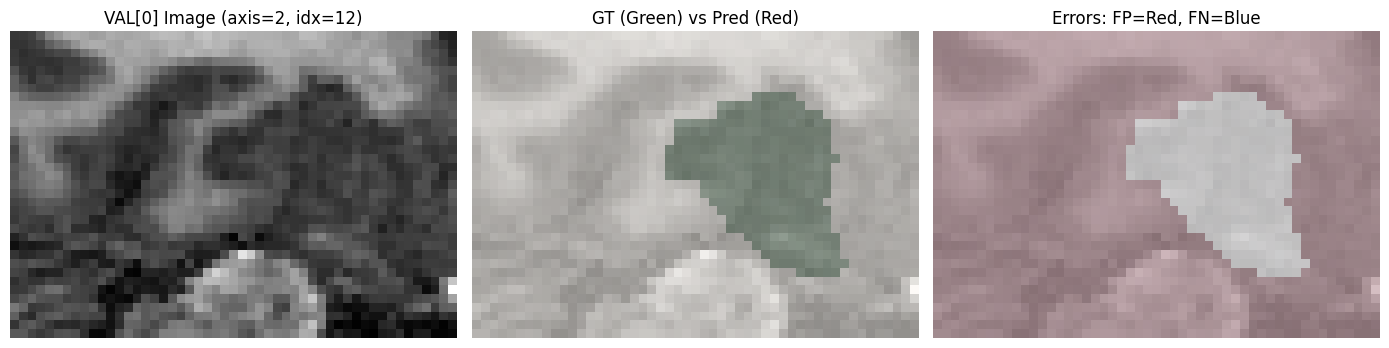

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()  # 이미 로드되어 있다고 가정

case_idx = 0  # 보고 싶은 val index

img_nii = nib.load(val_imgs[case_idx])
lab_nii = nib.load(val_labs[case_idx])

img = np.squeeze(img_nii.get_fdata()).astype(np.float32)
gt  = np.squeeze(lab_nii.get_fdata()).astype(np.int16)

img_norm = zscore_nonzero_np(img

pred, prob = sliding_window_predict_auto(
    model,
    img_norm,
    patch_size=(96,96,96),
    overlap=0.5,
    device=device
)

# GT가 0/1/2면 그대로 비교 가능, binary면 (gt>0)으로 통일하고 싶으면 아래 한 줄:
# gt = (gt > 0).astype(np.uint8)

visualize_case(img, gt, pred, axis=2, slice_idx=None, title_prefix=f"VAL[{case_idx}] ")